In [2]:
import sys
import os
import argparse
import time
from treeswift import *
import treeswift
import json
import numpy as np
import tskit
import random
import matplotlib.pyplot as plt
import multiple_tree_matching

def normalize_tree(tree):
	height = tree.height()
	for n in tree.traverse_preorder():
		if n.edge_length:
			n.edge_length /= height

def __label_tree__(tree_obj):
	is_labeled = True
	i = 0
	labels = set()
	for node in tree_obj.traverse_preorder():
		if not node.is_root():
			if not node.edge_length:
				node.edge_length = 0
		if node.is_leaf():
			continue
		if not node.label or node.label in labels or node.label[0] != 'I': 
			is_labeled = False
			node.label = 'I' + str(i)
			i += 1        
		labels.add(node.label)
	return is_labeled


def hmean(vals):
	y = [1/x for x in vals]
	return len(y) / np.sum(y)

def log_mean(vals):
	return np.exp(np.mean(np.log(vals)))

def compare_trees_pairwise_distances(tree1, tree2):
	# print(tree1, tree2)
	tree1_obj = read_tree_newick(tree1)
	tree2_obj = read_tree_newick(tree2)

	# normalize_tree(tree1_obj)
	# normalize_tree(tree2_obj)

	# print(tree1_obj.newick(), tree2_obj.newick())

	tree1_size = len([n.label for n in tree1_obj.traverse_leaves()])
	tree2_size = len([n.label for n in tree2_obj.traverse_leaves()])

	if tree1_size != tree2_size:
		print("Trees not the same size")
		return

	leaves = [n.label for n in tree2_obj.traverse_leaves()]

	dist_1 = tree1_obj.distance_matrix(leaf_labels=True)
	dist_2 = tree2_obj.distance_matrix(leaf_labels=True)

	MSE = 0
	for i in range(len(leaves)):
		for j in range(i+1,len(leaves)):
			l1 = leaves[i]
			l2 = leaves[j]
			MSE += (dist_1[l1][l2] - dist_2[l1][l2])**2

	total = len(leaves) * (len(leaves) - 1)/2
	return MSE/total

def lower_node_rate_map(tree: tskit.Tree, rates, dropped_index):
    index = -1
    node_to_rate = {}
    current = 0
    assert len(rates) + len(dropped_index) == 2 * (tree.num_samples())-1
    for nd in list(tree.nodes(order="postorder"))[0:]:
        index += 1
        if index in dropped_index:
            node_to_rate[nd] = None
        else:
            node_to_rate[nd] = rates[current]
            current += 1
    return node_to_rate


def compare_trees_TCMM(tree1:tskit.Tree, tree2:tskit.Tree):
	tree1_obj = read_tree_newick(tree1.as_newick())
	tree2_obj = read_tree_newick(tree2.as_newick())

	# normalize_tree(tree1_obj)
	# normalize_tree(tree2_obj)

	__label_tree__(tree1_obj)
	__label_tree__(tree2_obj)

	leaves = [n.label for n in tree1_obj.traverse_leaves()]

	new_tree, obj, rates, bls,dropped_index = multiple_tree_matching.compute_optimal_rates(tree1_obj, tree2_obj, r = 0)
	# print(dropped_index)
	# print(obj)
	rates = [float(r) for r in rates]

	node_to_rate=lower_node_rate_map(tree1,rates,dropped_index)

	return rates,node_to_rate

	# if method == 'mean':
	# 	return np.mean(rates) - 1 + np.std(rates)
	# if method == 'hmean':
	# 	return hmean(rates) - 1 + np.std(rates)
	# if method == 'log_mean':
	# 	return log_mean(rates) + np.std(rates)
	# print(norm_rates)
	# print(np.mean(norm_rates), np.std(norm_rates))
	# return obj
	# dist = log_mean(norm_rates) + np.std(norm_rates)
	# dist = np.mean(norm_rates) + np.std(norm_rates)
	return dist
def rates_mean(combined_rates,method):
    if method=="mean":
        return np.mean(combined_rates[-1])
    if method=="hmean":
        return hmean(combined_rates[-1])
    if method=="log_mean":
        return log_mean(combined_rates[-1])

In [3]:
true_arg=tskit.load("/Users/jinminli/research/tree_distance/simulations/small_diff_rate/Ne2e+04_r1e-08_100_1e+06/0/Ne2e+04_r1e-08_100_1e+06_0.trees")
inferred_arg=tskit.load("/Users/jinminli/research/tree_distance/simulations/small_diff_rate/Ne2e+04_r1e-08_100_1e+06/0/singer_inferred/Ne2e+04_r1e-08_100_1e+06_49.trees")

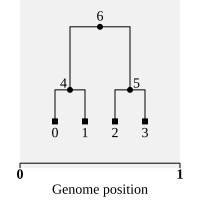

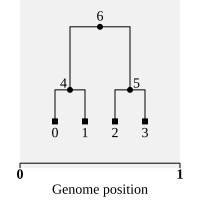

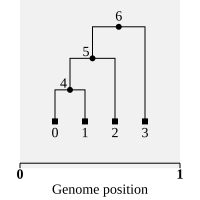

In [1]:
import tskit
import io
from IPython.display import display, SVG


nodes1 = """\
is_sample   individual   time
1           -1           0
1           -1           0
1           -1           0
1           -1           0
0           -1           1
0           -1           1
0           -1           3
"""

edges1 = """\
left   right   parent  child
0      1       4       0
0      1       4       1
0      1       5       2
0      1       5       3
0      1       6       4
0      1       6       5
"""
ts1 = tskit.load_text(
    nodes=io.StringIO(nodes1),
    edges=io.StringIO(edges1),
    strict=False
)
display(ts1.draw_svg())
nodes2 = """\
is_sample   individual   time
1   -1   0      # 0
1   -1   0      # 1
1   -1   0      # 2
1   -1   0      # 3
0   -1   1      # 4 = coalescence of (0,2)
0   -1   2      # 5 = coalescence of (4,1)
0   -1   3      # 6 = coalescence of (5,3)
"""

edges2 = """\
left   right   parent  child
0   1   4   0
0   1   4   1

0   1   5   4
0   1   5   2

0   1   6   5
0   1   6   3
"""
ts2 = tskit.load_text(
    nodes=io.StringIO(nodes2),
    edges=io.StringIO(edges2),
    strict=False
)
display(ts2.draw_svg())

In [6]:
rates,node_to_rates=compare_trees_TCMM(ts1.at(0),ts2.at(0))

Polishing not needed - no active set detected at optimal point


In [7]:
node_to_rates

{0: 0.9999890551507351,
 1: 0.9999890551507347,
 4: 0.2500071146898423,
 2: 1.999989055147102,
 3: 3.9999890551398387,
 5: 0.2500071146898423,
 6: None}